In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
# sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
# import kuaizi
# from kuaizi.display import display_single
# kuaizi.set_env(project='SBF', name='Rosesim', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
# kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)

sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

In [2]:
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

In [3]:
obs_ra, obs_dec = 150, 0

DATA_PATH = rosesim.DATA_PATH

In [4]:
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e6.0_4.0Mpc_age9.0_feh-1.5')

In [5]:
# import astrocut
# from astrocut import ASDFCutout

In [ ]:
for filt in ['F106', 'F129', 'F158']:
    for i in range(4):
        dm = rosesim.utils.read_L3_asdf(f'./{filt}_600s.dither{i}.asdf')
        rosesim.utils.asdf_to_fits(dm, f'./{filt}_600s.dither{i}.fits')

In [6]:
res = fits.open('./F106_600s.dither0.fits')[0].data - fits.open('./F106_600s.dither2.fits')[0].data

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f60d423c050>})

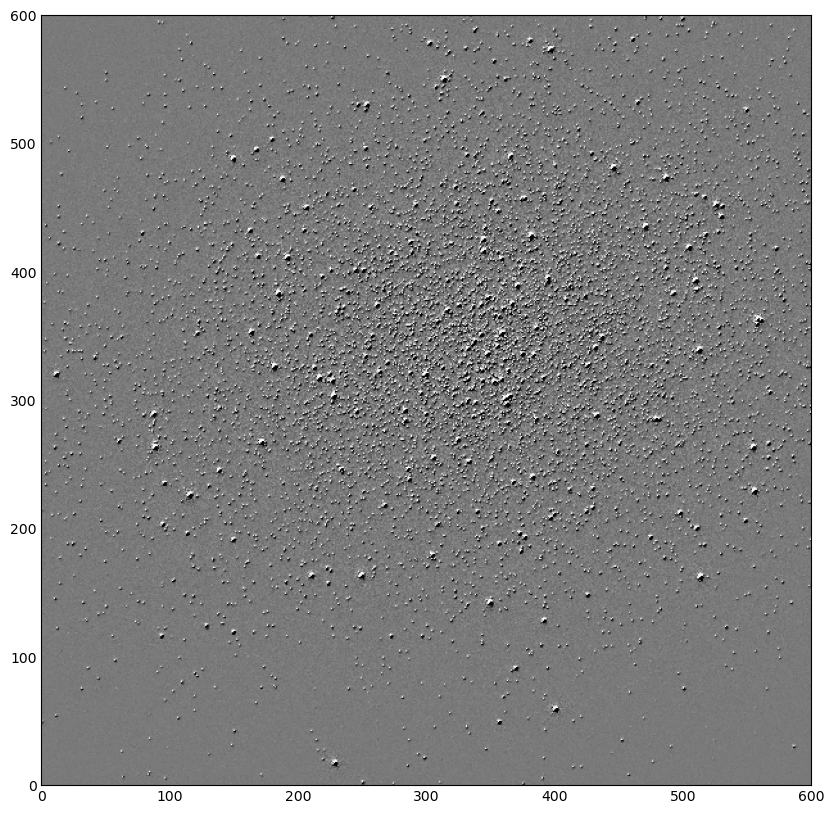

In [7]:
show_image_wcs(res[1700:2300, 1700:2300])

In [6]:

# # Choose an output pixel scale finer than native to improve sampling.
# # If native is ~0.11 arcsec/pix, try 0.055 arcsec/pix as a starting point.
# final_scale = 0.055  # arcsec/pixel
# for filename in input_files:
#     with fits.open(filename, mode='update') as hdul:
#         hdr = hdul[0].header
#         hdr['PA_V3'] = (0, 'Dummy V3 position angle (deg)')
#         hdr['INSTRUME'] = 'ACS'
#         hdr['DETECTOR'] = '01'
#         hdr['EXPTIME'] = 600
#         hdul.flush()

In [14]:
def get_subpixel_dither(obs_ra, obs_dec,
                        dither_pattern='SUB4'):
    if dither_pattern=='SUB4':
        # Default SUB4 pattern (arcsec)
        dither_pattern = np.array([
            (0.0000,  0.0000),  (-0.0825, -0.0275),
            (-0.0275,  0.0550), (0.0550,   0.0825)
        ]) / 3600.0
    else:
        raise ValueError
    cos_dec = np.cos(np.deg2rad(obs_dec))
    offsets = [(dra / cos_dec, ddec) for dra, ddec in dither_pattern]
    return offsets

In [15]:
dither_pattern = get_subpixel_dither(obs_ra, obs_dec)

In [74]:
from drizzle.resample import Drizzle
from drizzle.utils import calc_pixmap
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs import WCS

images = []
wcs_list = []

filt = 'F106'
for i in range(4):
# input_files = [f'./F106_600s.dither{i}.fits' for i in range(4)]
# for f in input_files:
    file = f'./{filt}_600s.dither{i}.fits'
    hdul = fits.open(file)
    images.append(hdul[0].data)
    w = WCS(hdul[0].header)
    w.wcs.crval -= dither_pattern[i]
    wcs_list.append(w)
    hdul.close()

# Use first image as reference
ref_wcs = wcs_list[0]
ref_shape = images[0].shape
ny, nx = ref_shape

scale_factor = 2  # set to 2 if you want half-pixel output sampling
out_wcs = ref_wcs.deepcopy()
if out_wcs.wcs.has_cd():
    out_wcs.wcs.cd = out_wcs.wcs.cd / scale_factor
else:
    out_wcs.wcs.cdelt = out_wcs.wcs.cdelt / scale_factor
out_wcs.wcs.crpix = (np.array(out_wcs.wcs.crpix) - 0.5) * scale_factor + 0.5

out_shape = (int(ny * scale_factor), int(nx * scale_factor))
out_wcs.array_shape = out_shape

d = Drizzle(out_shape=out_shape, kernel="square")

for img, in_wcs in zip(images[:], wcs_list[:]):
    pixmap = calc_pixmap(in_wcs, out_wcs, shape=img.shape)
    in_wht = np.ones_like(img, dtype=np.float32)
    d.add_image(img, exptime=600.0, pixmap=pixmap, pixfrac=0.7, weight_map=in_wht)

In [75]:
print("out_img shape:", d.out_img.shape)
print("out_wht shape:", d.out_wht.shape)
print("out_ctx shape:", d.out_ctx.shape)
# print("exptime total :", d.exptime)

# Quick sanity checks: total flux should be ~ conserved (modulo edge losses)
# print("input sum:", np.nansum(data))
print("drz   sum:", np.nansum(d.out_img))

out_img shape: (8192, 8192)
out_wht shape: (8192, 8192)
out_ctx shape: (1, 8192, 8192)
drz   sum: 26318.832


In [76]:
hdu = fits.PrimaryHDU(d.out_img, header=out_wcs.to_header())
hdu.writeto(f"{filt}_drizzled.fits", overwrite=True)

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7fd9b073b150>})

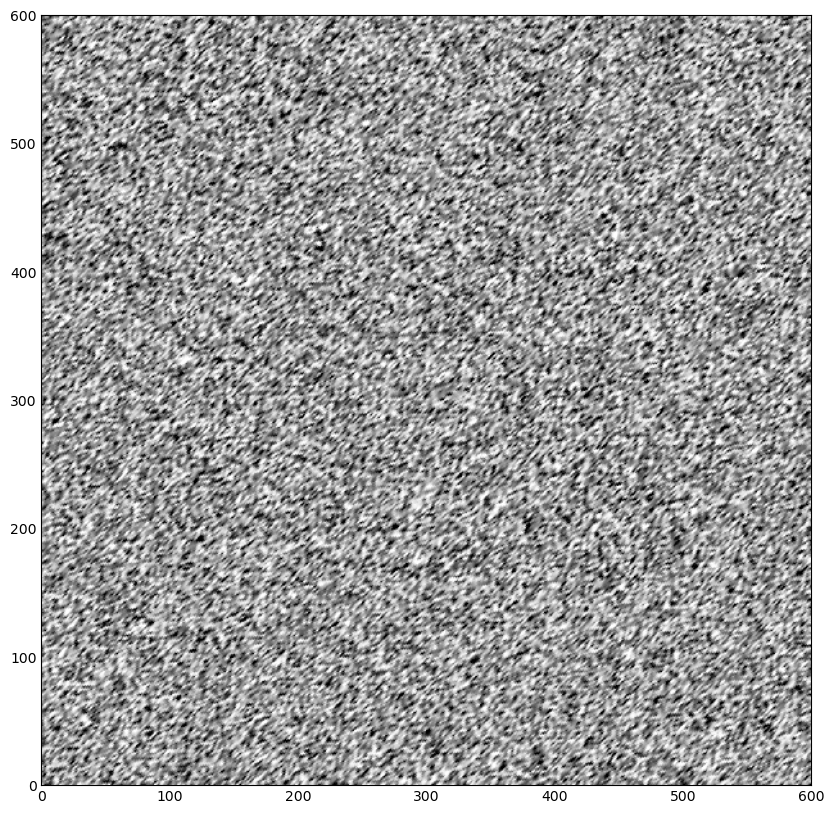

In [67]:
show_image_wcs(d.out_img[1700:2300,1700:2300])

In [71]:
from astropy.visualization import make_lupton_rgb
import sep

zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [99]:
x = 100
x2 = int(x*2)
imgs = [fits.open(f'./{filt}_drizzled.fits')[0].data[4096-x2:4096+x2,4096-x2:4096+x2] for filt in ['F106', 'F129', 'F158']]

# imgs = [fits.open(f'./{filt}_600s.dither0.fits')[0].data[2048-x:2048+x,2048-x:2048+x] for filt in ['F106', 'F129', 'F158']]

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

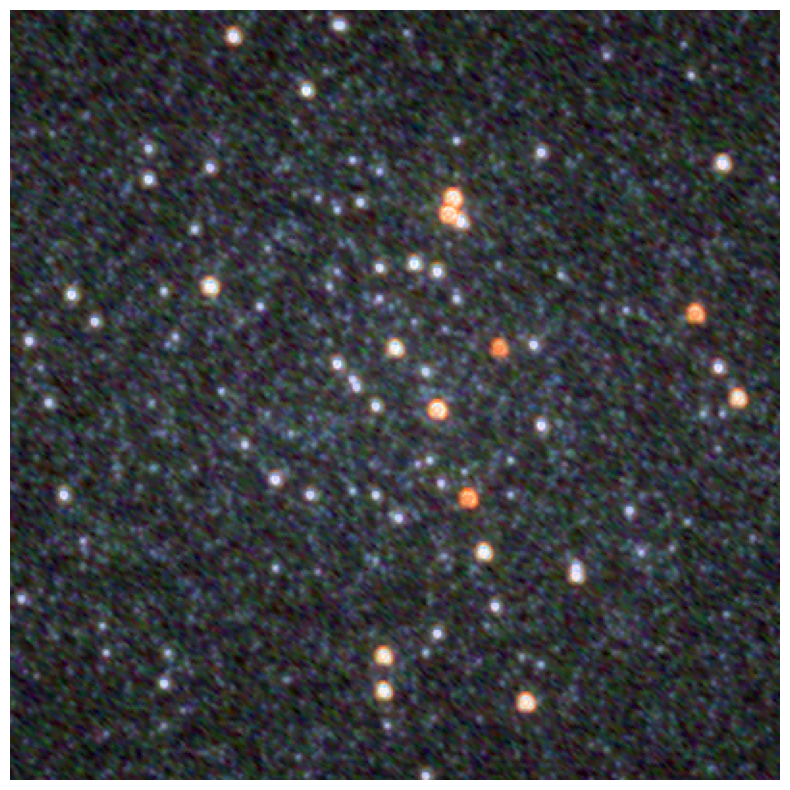

In [100]:
rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
# rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=3)
fig, ax = plt.subplots(figsize=(10, 10))
# fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb) #, origin='lower')
plt.axis('off')